# GA Convergence Heatmap

Visualizes how the GA-optimized mutation path improves across generations.

- **X-axis**: Mutation step (number of mutations applied)
- **Y-axis**: Z-score distance (`|z_E1| + |z_E2|`)
- **Lines**: Best path at evenly-spaced generation snapshots, colored by generation (light = early, dark = late)

In [34]:
# =============================================================================
# PARAMETERS
# =============================================================================

# Visualization
N_LINES = 65                # Number of path snapshots to plot

# Protein families
PROTEIN_1 = 'PF00004'
PROTEIN_2 = 'PF00041'
OVERLAP = 12

# Sequence generation
N_SEQUENCES = 15
MC_ITERATIONS = 250_000
MC_TEMP_1 = 0.818
MC_TEMP_2 = 0.955

# GA parameters
GA_POPULATION = 75
GA_GENERATIONS = 100
GA_MUTATION_RATE = 0.15

# Stop-codon-free retry limits
MAX_INIT_RETRIES = 1000000
MAX_MUTATION_RETRIES = 10
MAX_CROSSOVER_RETRIES = 10

# Normalization
Z_SCORE = True


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from tqdm.auto import tqdm
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')
# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('PuBuGn')
plt.rcParams['figure.figsize'] = (12, 8)

sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.9)

import overlappingGenes as og
from ga_worker import (
    seq_to_array, get_mutations_arrays, get_mutation_path,
    is_path_stop_codon_free,
    evaluate_population_parallel, evaluate_path_fitness_numba,
    get_path_energies,
    hamming_distance, find_closest_pair
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Load DCA parameters
print(f"Loading DCA parameters for {PROTEIN_1}...")
Jvec_1, hvec_1 = og.extract_params(f'bmDCA/{PROTEIN_1}/{PROTEIN_1}_params.dat')
nat_energies_1 = og.load_natural_energies(f'bmDCA/{PROTEIN_1}/{PROTEIN_1}_naturalenergies.txt')
mean_e1, std_e1 = np.mean(nat_energies_1), np.std(nat_energies_1)
print(f"  Length: {len(hvec_1)//21} AA, Mean energy: {mean_e1:.2f} +/- {std_e1:.2f}")

print(f"\nLoading DCA parameters for {PROTEIN_2}...")
Jvec_2, hvec_2 = og.extract_params(f'bmDCA/{PROTEIN_2}/{PROTEIN_2}_params.dat')
nat_energies_2 = og.load_natural_energies(f'bmDCA/{PROTEIN_2}/{PROTEIN_2}_naturalenergies.txt')
mean_e2, std_e2 = np.mean(nat_energies_2), np.std(nat_energies_2)
print(f"  Length: {len(hvec_2)//21} AA, Mean energy: {mean_e2:.2f} +/- {std_e2:.2f}")

DCA_params_1 = (Jvec_1, hvec_1)
DCA_params_2 = (Jvec_2, hvec_2)

prot1_len = len(hvec_1) // 21
prot2_len = len(hvec_2) // 21
len_aa_1 = prot1_len + 1
len_aa_2 = prot2_len + 1

# JIT warmup
print("\nWarming up JIT compilation...")
test_seq = og.initial_seq_no_stops(prot1_len, prot2_len, OVERLAP, quiet=True)
_ = og.overlapped_sequence_generator_int(
    DCA_params_1, DCA_params_2, test_seq,
    T1=MC_TEMP_1, T2=MC_TEMP_2,
    numberofiterations=1000, quiet=True,
    nat_mean1=mean_e1, nat_mean2=mean_e2,
    nat_std1=std_e1, nat_std2=std_e2,
    use_z_score=Z_SCORE
)
test_arr = seq_to_array(test_seq)
test_positions = np.array([0, 1, 2], dtype=np.int32)
test_new_nts = np.array([0, 1, 2], dtype=np.uint8)
test_order = np.array([0, 1, 2], dtype=np.int32)
_ = is_path_stop_codon_free(test_order, test_arr, test_positions, test_new_nts, len_aa_1, len_aa_2)
print("Done!")

Loading DCA parameters for PF00004...
  Length: 110 AA, Mean energy: 145.88 +/- 38.25

Loading DCA parameters for PF00041...
  Length: 74 AA, Mean energy: 120.66 +/- 17.64

Warming up JIT compilation...
Done!


In [36]:
# Generate functional sequences
sequences = []
energies = []

print(f"Generating {N_SEQUENCES} functional sequences...")
for i in tqdm(range(N_SEQUENCES)):
    initial_seq = og.initial_seq_no_stops(prot1_len, prot2_len, OVERLAP, quiet=True)
    result = og.overlapped_sequence_generator_int(
        DCA_params_1, DCA_params_2, initial_seq,
        T1=MC_TEMP_1, T2=MC_TEMP_2,
        numberofiterations=MC_ITERATIONS, quiet=True, whentosave=100.0,
        nat_mean1=mean_e1, nat_mean2=mean_e2,
        nat_std1=std_e1, nat_std2=std_e2, use_z_score=Z_SCORE
    )
    sequences.append(result[6])   # best sequence
    energies.append(result[5])    # best energies [E1, E2]

energies = np.array(energies)
print(f"Generated {len(sequences)} sequences")
print(f"Energy range (E1): {energies[:, 0].min():.2f} to {energies[:, 0].max():.2f}")
print(f"Energy range (E2): {energies[:, 1].min():.2f} to {energies[:, 1].max():.2f}")

Generating 15 functional sequences...


100%|██████████| 15/15 [00:02<00:00,  5.10it/s]

Generated 15 sequences
Energy range (E1): 145.66 to 146.16
Energy range (E2): 120.62 to 120.81


In [37]:
# Select closest sequence pair
(p1, p2), ham_dist = find_closest_pair(sequences)
seq_start = sequences[p1]
seq_end = sequences[p2]
n_mutations = hamming_distance(seq_start, seq_end)
print(f"Selected pair ({p1}, {p2}): Hamming distance = {ham_dist}, mutations = {n_mutations}")

Selected pair (1, 8): Hamming distance = 261, mutations = 261


In [38]:
def run_ga_with_snapshots(seq_start, seq_end,
                          Jvec1, hvec1, Jvec2, hvec2,
                          len_aa_1, len_aa_2,
                          mean_e1, mean_e2, std_e1, std_e2, z_score,
                          ga_pop, ga_gen, ga_mut_rate,
                          max_init_retries, max_mutation_retries, max_crossover_retries,
                          n_lines=10):
    """
    Run GA and capture path snapshots at evenly-spaced generation intervals.
    n_lines controls how many snapshots to record.
    """
    seq_arr = seq_to_array(seq_start)
    mut_positions, mut_old_nts, mut_new_nts = get_mutations_arrays(seq_start, seq_end)
    mutations = get_mutation_path(seq_start, seq_end)
    n_mutations = len(mut_positions)

    if n_mutations == 0:
        return None

    nat_std_1 = std_e1 if std_e1 is not None else 1.0
    nat_std_2 = std_e2 if std_e2 is not None else 1.0

    def is_valid_path(path):
        return is_path_stop_codon_free(path, seq_arr, mut_positions, mut_new_nts, len_aa_1, len_aa_2)

    # Compute snapshot generations from n_lines
    snapshot_interval = max(1, ga_gen // n_lines)
    snapshot_gens = set(range(0, ga_gen + 1, snapshot_interval))
    snapshot_gens.add(ga_gen)  # always include final

    # Initialize population (stop-codon-free)
    population = np.zeros((ga_pop, n_mutations), dtype=np.int32)
    for i in range(ga_pop):
        for attempt in range(max_init_retries):
            candidate = np.random.permutation(n_mutations).astype(np.int32)
            if is_valid_path(candidate):
                population[i] = candidate
                break
        else:
            raise RuntimeError(f"Could not initialize population after {max_init_retries} attempts")

    elitism_count = max(1, int(0.1 * ga_pop))
    snapshots = []

    # Initial best
    best_individual = population[0].copy()
    best_fitness = evaluate_path_fitness_numba(
        best_individual, seq_arr, mut_positions, mut_new_nts,
        Jvec1, hvec1, Jvec2, hvec2, len_aa_1, len_aa_2,
        mean_e1, mean_e2, nat_std_1, nat_std_2, z_score
    )

    # Record generation 0 snapshot
    if 0 in snapshot_gens:
        _, init_distances = get_path_energies(
            best_individual.tolist(), seq_start, mutations,
            Jvec1, hvec1, Jvec2, hvec2, len_aa_1, len_aa_2,
            mean_e1, mean_e2, nat_std_1=nat_std_1, nat_std_2=nat_std_2, z_score=z_score
        )
        snapshots.append((0, init_distances))

    # GA loop
    for gen in tqdm(range(ga_gen), desc="GA"):
        fitnesses = evaluate_population_parallel(
            population, seq_arr, mut_positions, mut_new_nts,
            Jvec1, hvec1, Jvec2, hvec2, len_aa_1, len_aa_2,
            mean_e1, mean_e2, nat_std_1, nat_std_2, z_score
        )

        gen_best_idx = np.argmin(fitnesses)
        if fitnesses[gen_best_idx] < best_fitness:
            best_fitness = fitnesses[gen_best_idx]
            best_individual = population[gen_best_idx].copy()

        # Snapshot check
        if (gen + 1) in snapshot_gens:
            _, path_distances = get_path_energies(
                best_individual.tolist(), seq_start, mutations,
                Jvec1, hvec1, Jvec2, hvec2, len_aa_1, len_aa_2,
                mean_e1, mean_e2, nat_std_1=nat_std_1, nat_std_2=nat_std_2, z_score=z_score
            )
            snapshots.append((gen + 1, path_distances))

        # Selection and reproduction
        sorted_idx = np.argsort(fitnesses)
        new_population = np.zeros_like(population)

        for i in range(elitism_count):
            new_population[i] = population[sorted_idx[i]]

        idx = elitism_count
        while idx < ga_pop:
            p1_idx = sorted_idx[np.random.choice(ga_pop // 2)]
            p2_idx = sorted_idx[np.random.choice(ga_pop // 2)]
            parent1, parent2 = population[p1_idx], population[p2_idx]

            # Crossover with stop-codon-free guarantee
            size = len(parent1)
            child = None
            for _ in range(max_crossover_retries):
                start, end = sorted(np.random.choice(size, 2, replace=False))
                candidate = np.full(size, -1, dtype=np.int32)
                candidate[start:end] = parent1[start:end]
                in_child = set(candidate[start:end])
                p2_remaining = [x for x in parent2 if x not in in_child]
                fill_idx = 0
                for i in range(size):
                    if candidate[i] == -1:
                        candidate[i] = p2_remaining[fill_idx]
                        fill_idx += 1
                if is_valid_path(candidate):
                    child = candidate
                    break
            if child is None:
                child = parent1.copy() if np.random.rand() < 0.5 else parent2.copy()

            # Mutation with stop-codon-free guarantee
            if np.random.rand() < ga_mut_rate and len(child) >= 2:
                original = child.copy()
                for _ in range(max_mutation_retries):
                    mutated = original.copy()
                    i, j = np.random.choice(len(mutated), 2, replace=False)
                    mutated[i], mutated[j] = mutated[j], mutated[i]
                    if is_valid_path(mutated):
                        child = mutated
                        break

            new_population[idx] = child
            idx += 1

        population = new_population

    return {
        'snapshots': snapshots,
        'best_fitness': best_fitness,
        'best_order': best_individual.tolist(),
        'n_mutations': n_mutations
    }

print("run_ga_with_snapshots() defined.")

run_ga_with_snapshots() defined.


In [39]:
# Run GA with snapshot tracking
result = run_ga_with_snapshots(
    seq_start, seq_end,
    Jvec_1, hvec_1, Jvec_2, hvec_2,
    len_aa_1, len_aa_2,
    mean_e1, mean_e2, std_e1, std_e2, Z_SCORE,
    GA_POPULATION, GA_GENERATIONS, GA_MUTATION_RATE,
    MAX_INIT_RETRIES, MAX_MUTATION_RETRIES, MAX_CROSSOVER_RETRIES,
    n_lines=N_LINES
)

snapshots = result['snapshots']
print(f"Captured {len(snapshots)} snapshots at generations: {[s[0] for s in snapshots]}")
print(f"Final best fitness (max z-score distance): {result['best_fitness']:.4f}")
print(f"Total mutations in path: {result['n_mutations']}")

GA: 100%|██████████| 100/100 [00:19<00:00,  5.19it/s]

Captured 101 snapshots at generations: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
Final best fitness (max z-score distance): 0.1965
Total mutations in path: 261


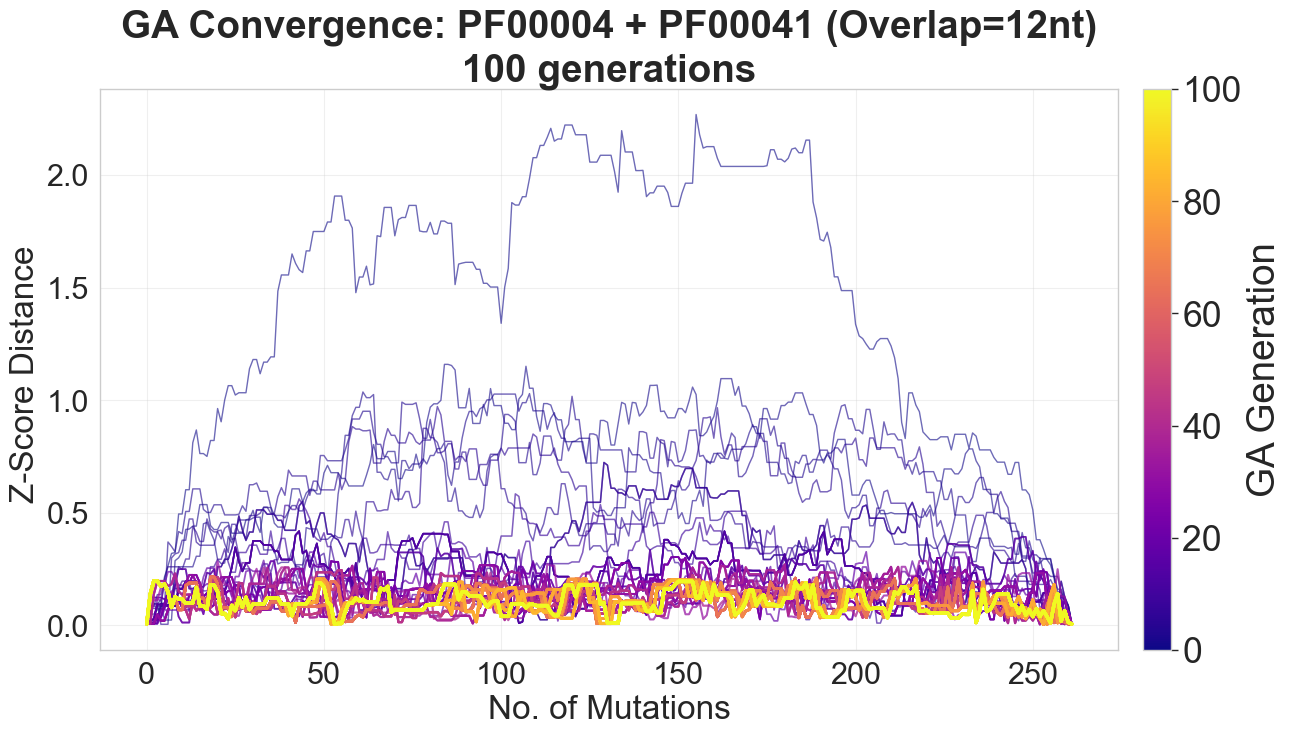

In [45]:
# Convergence heatmap plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_context("paper", font_scale=2.9)
gen_numbers = [s[0] for s in snapshots]
max_gen = max(gen_numbers)

cmap = cm.plasma
norm = Normalize(vmin=0, vmax=max_gen)

for gen, path_distances in snapshots:
    color = cmap(norm(gen))
    x = np.arange(len(path_distances))
    # Early lines: more transparent and thinner; late lines: opaque and thicker
    t = gen / max_gen if max_gen > 0 else 1.0
    alpha = 0.6 + 0.4 * t
    linewidth = 1.0 + 1.5 * t
    ax.plot(x, path_distances, '-', color=color, alpha=alpha, linewidth=linewidth)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('GA Generation')

ax.set_xlabel('No. of Mutations')
ax.set_ylabel('Z-Score Distance ')
ax.set_title(
    f'GA Convergence: {PROTEIN_1} + {PROTEIN_2} (Overlap={OVERLAP}nt)\n'
    f'{GA_GENERATIONS} generations',
     fontweight='bold'
)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ga_convergence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()